# Squidpy Benchmark — Sampled Lymph Node (5k & 50k)

This notebook runs the Squidpy spatial niche identification pipeline sequentially on two sampled datasets:
1. `lymph_node_5k_random3.h5ad`
2. `lymph_node_50k_random3.h5ad`

All outputs (figures and annotated AnnData) are saved to the `results/` directory with prefixes `5k_squidpy_` and `50k_squidpy_`.

In [ ]:
try:
    import google.colab
    ENV = "colab"
except ImportError:
    ENV = "jupyter"

print(f"Running in: {ENV}")

Running in: colab


In [ ]:
# 0. Install dependencies
import os
_pkgs = (
    "'numpy>=1.24' "
    "'zarr>=2.12,<3.0.0' "
    "'anndata>=0.9,<0.11.0' "
    "'scanpy>=1.9,<1.10.0' "
    "'spatialdata>=0.1,<0.5.0' "
    "'spatialdata-io<0.5.0' "
    "'squidpy>=1.3,<1.7.0' "
    "'leidenalg' "
    "'louvain' "
    "'dask-image' "
    "'datashader' "
    "'pyarrow' "
)

if ENV == "colab":
    get_ipython().system(f"pip install -q {_pkgs}")
else:
    if not os.environ.get("SKIP_INSTALL"):
        get_ipython().system(f"pip install -q {_pkgs}")

# Removed autoreload as it's incompatible with Python 3.12 due to the removal of the 'imp' module.
# %load_ext autoreload
# %autoreload 2


Processing 5k sampled dataset

loaded: 4,975 cells x 4624 features
n_cells after spatial crop: 772


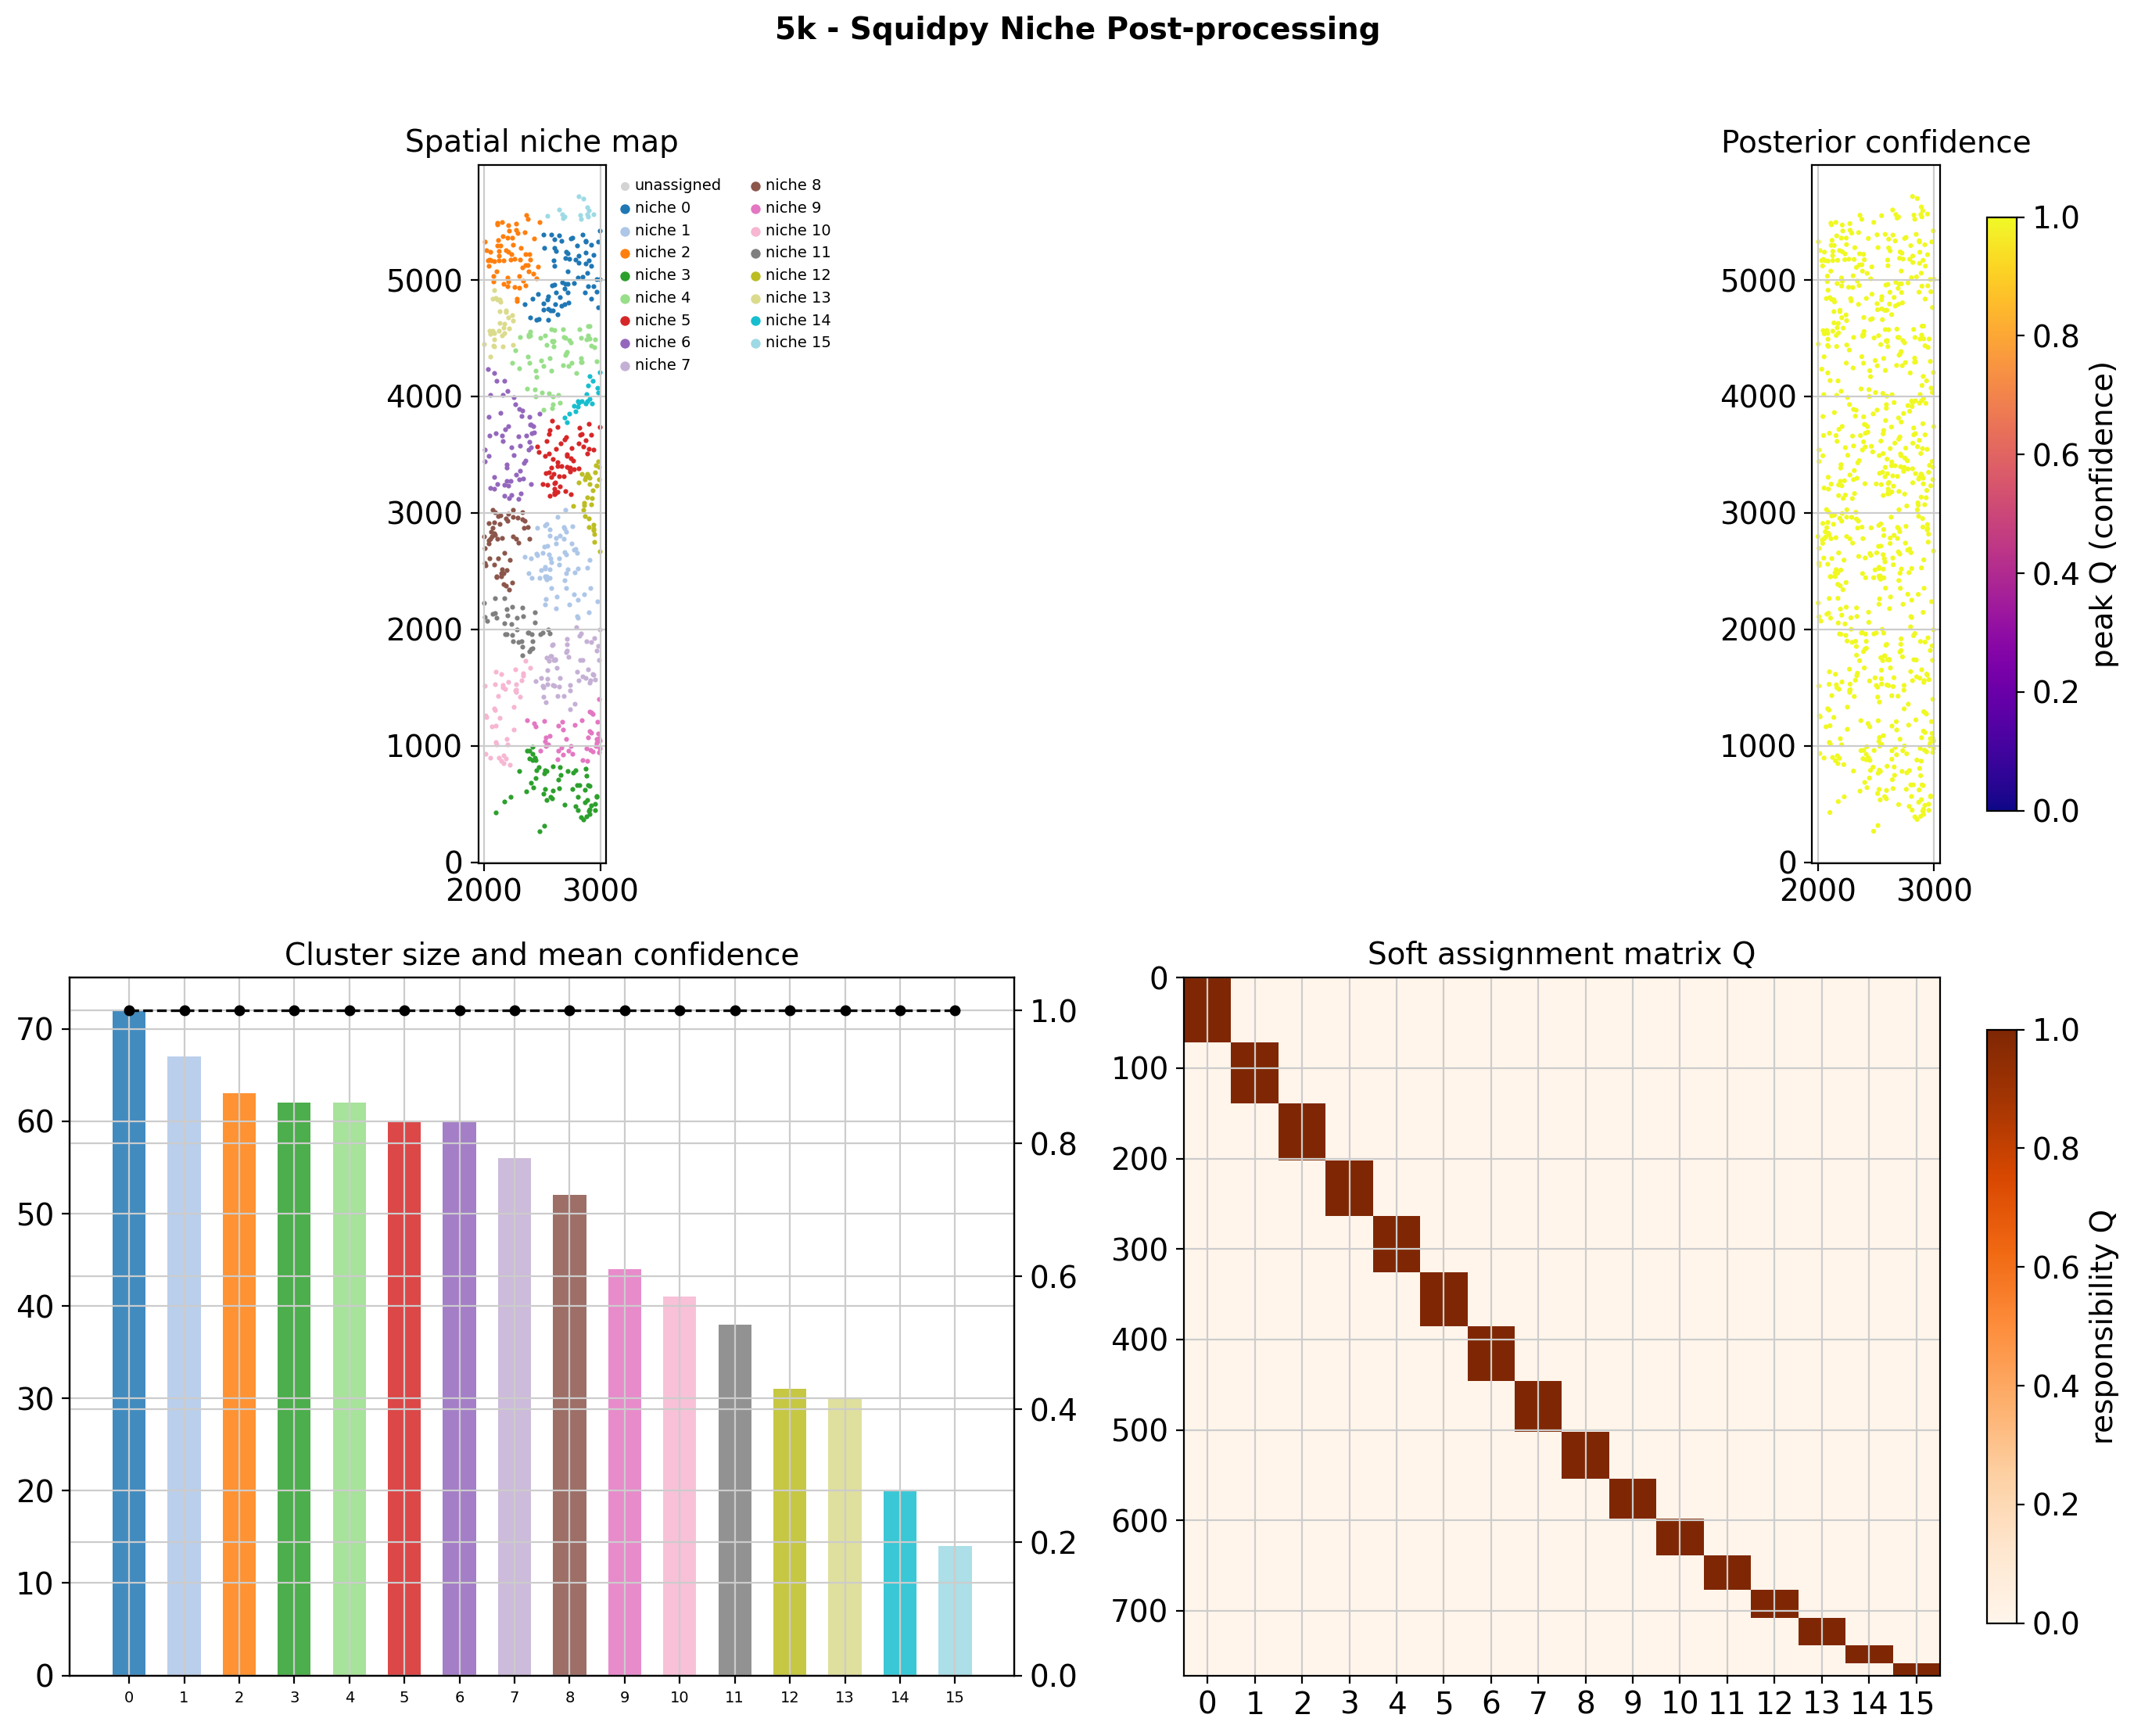

  0%|          | 0/1000 [00:00<?, ?/s]

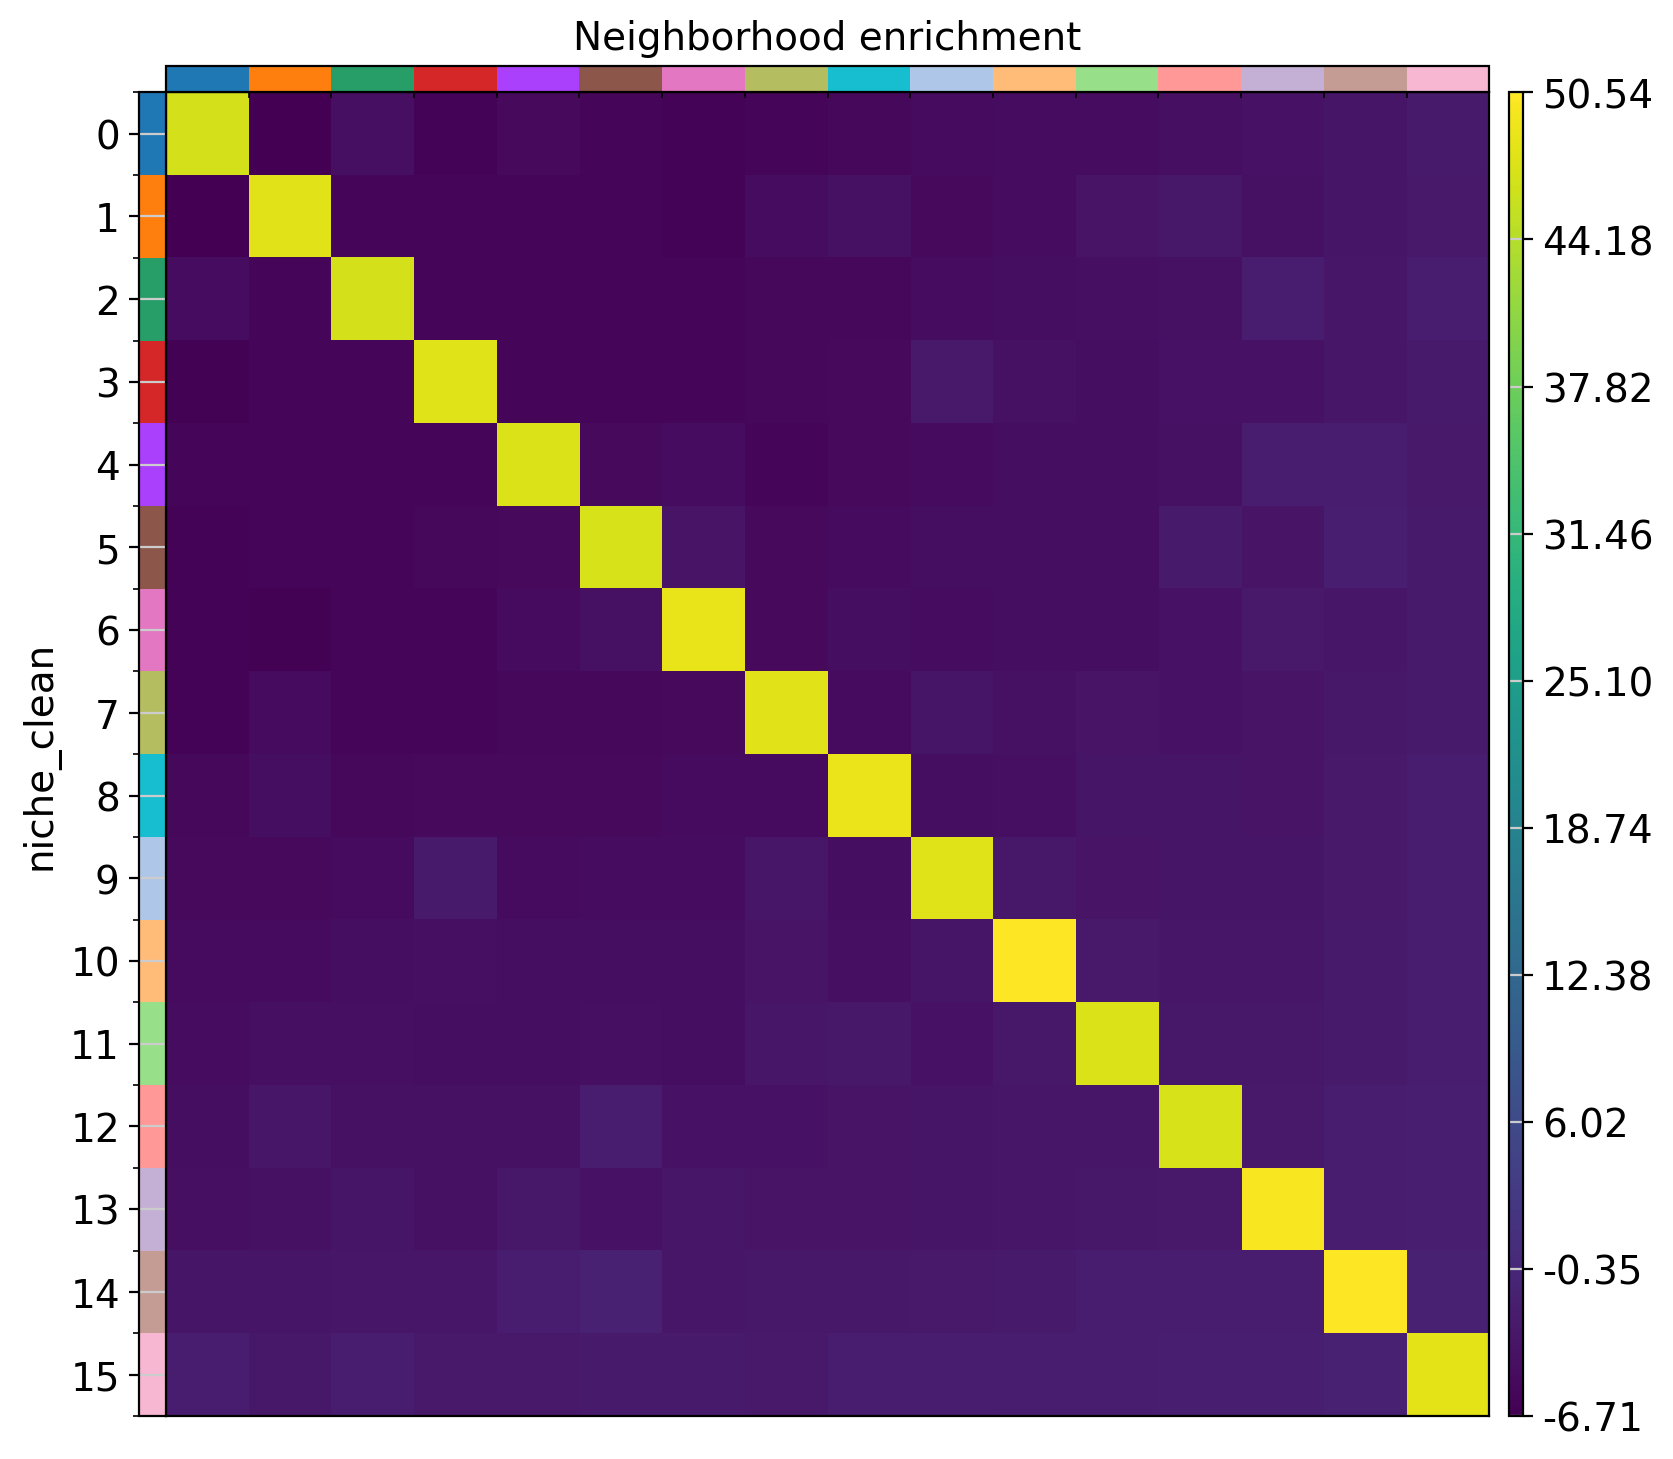

ERROR: Unable to fetch palette, reason: 'niche_clean_colors'. Using `None`.


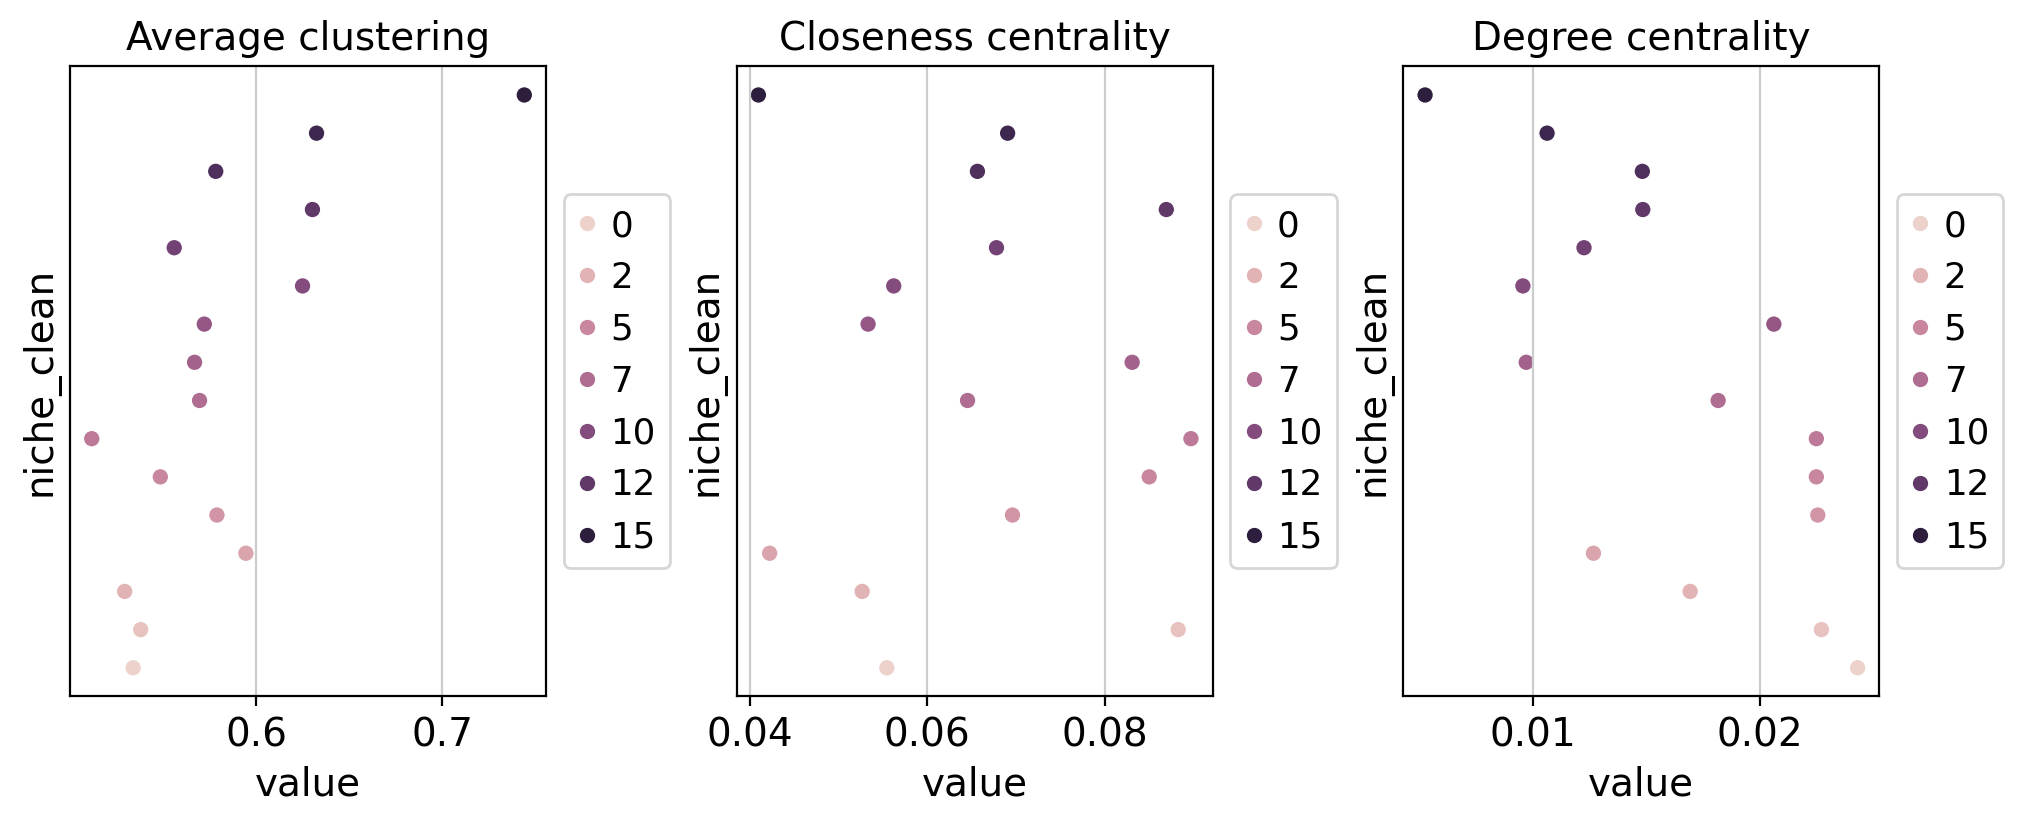

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


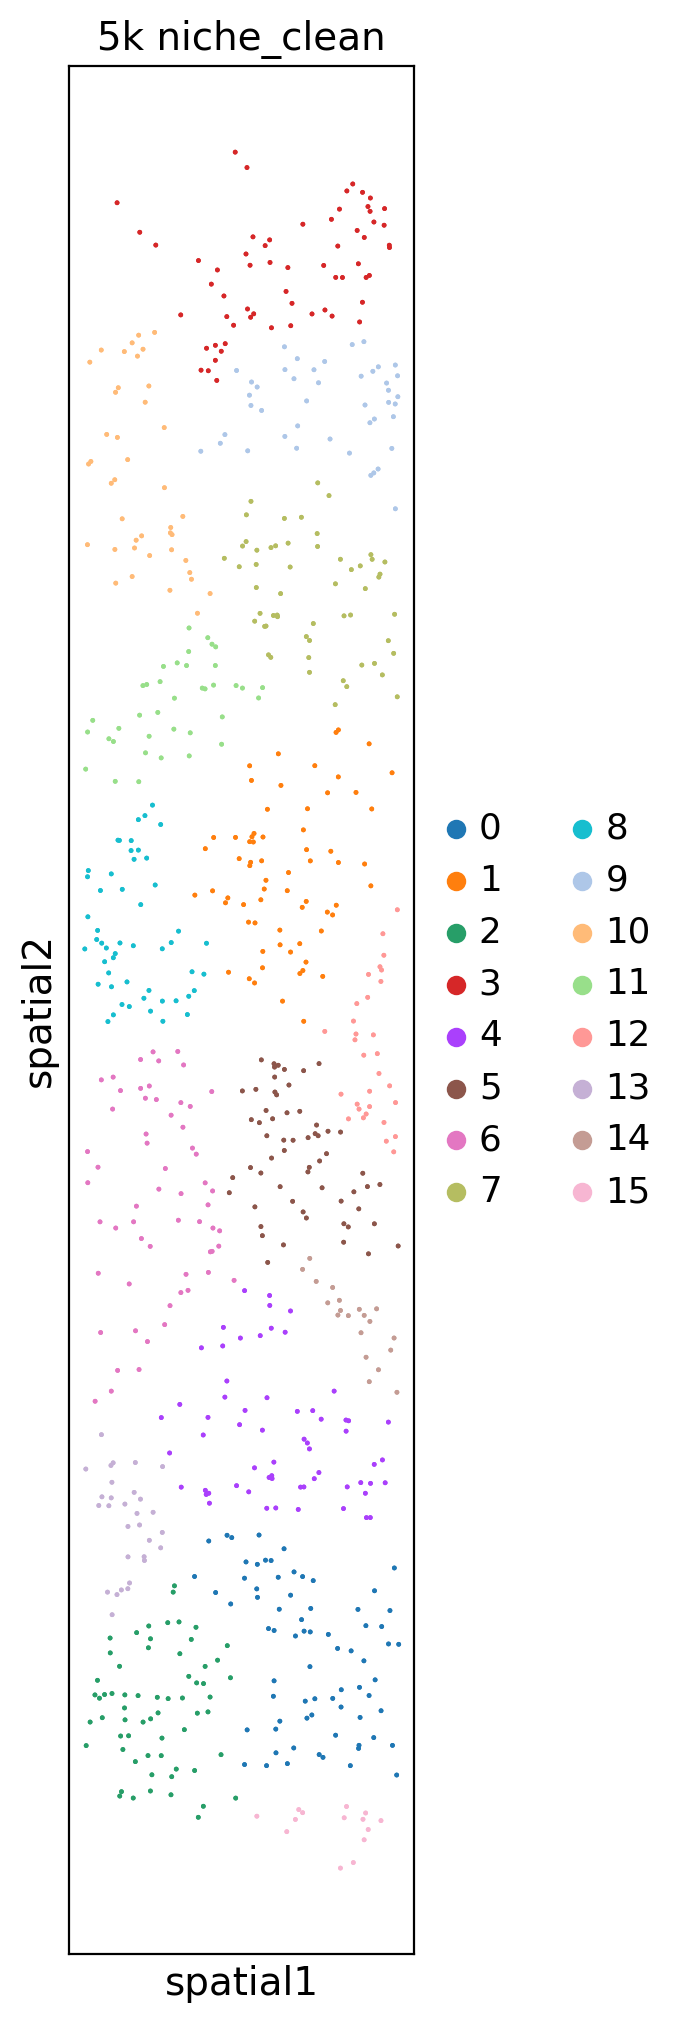

saved: /content/drive/MyDrive/CBMF4761/results/5k_squidpy.h5ad

Processing 50k sampled dataset

loaded: 49,717 cells x 4624 features
n_cells after spatial crop: 7753


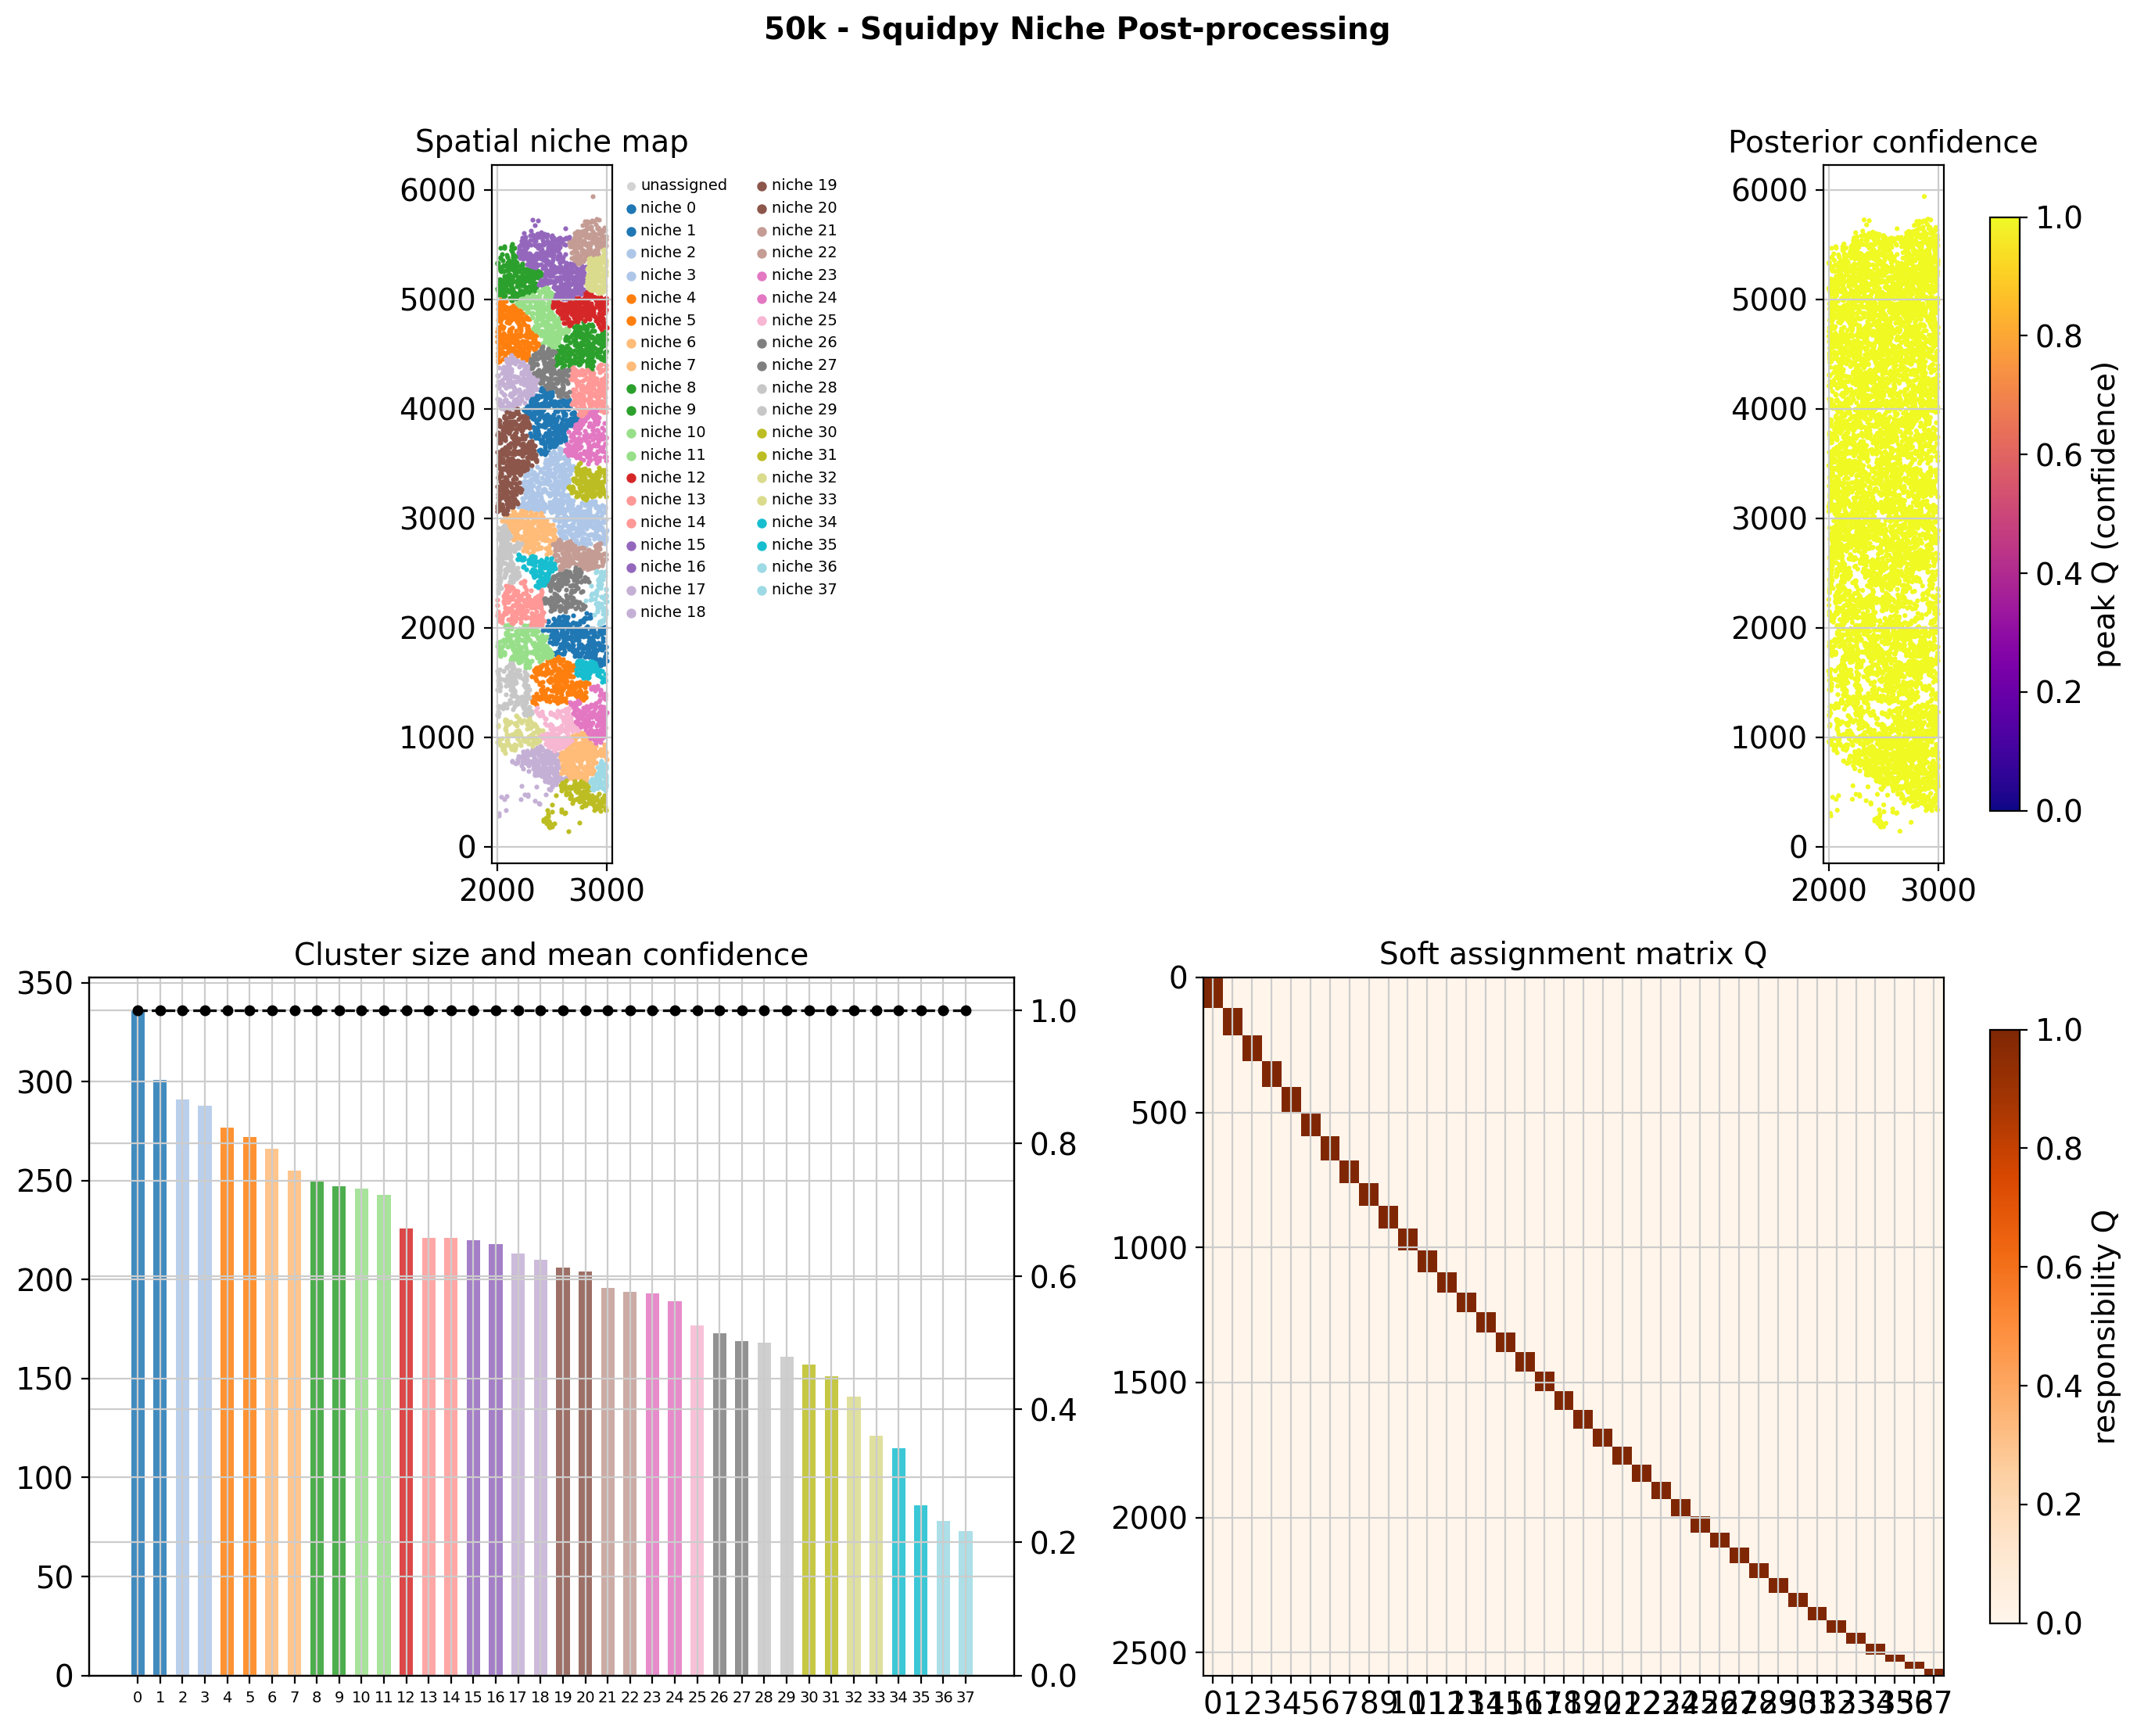

  0%|          | 0/1000 [00:00<?, ?/s]

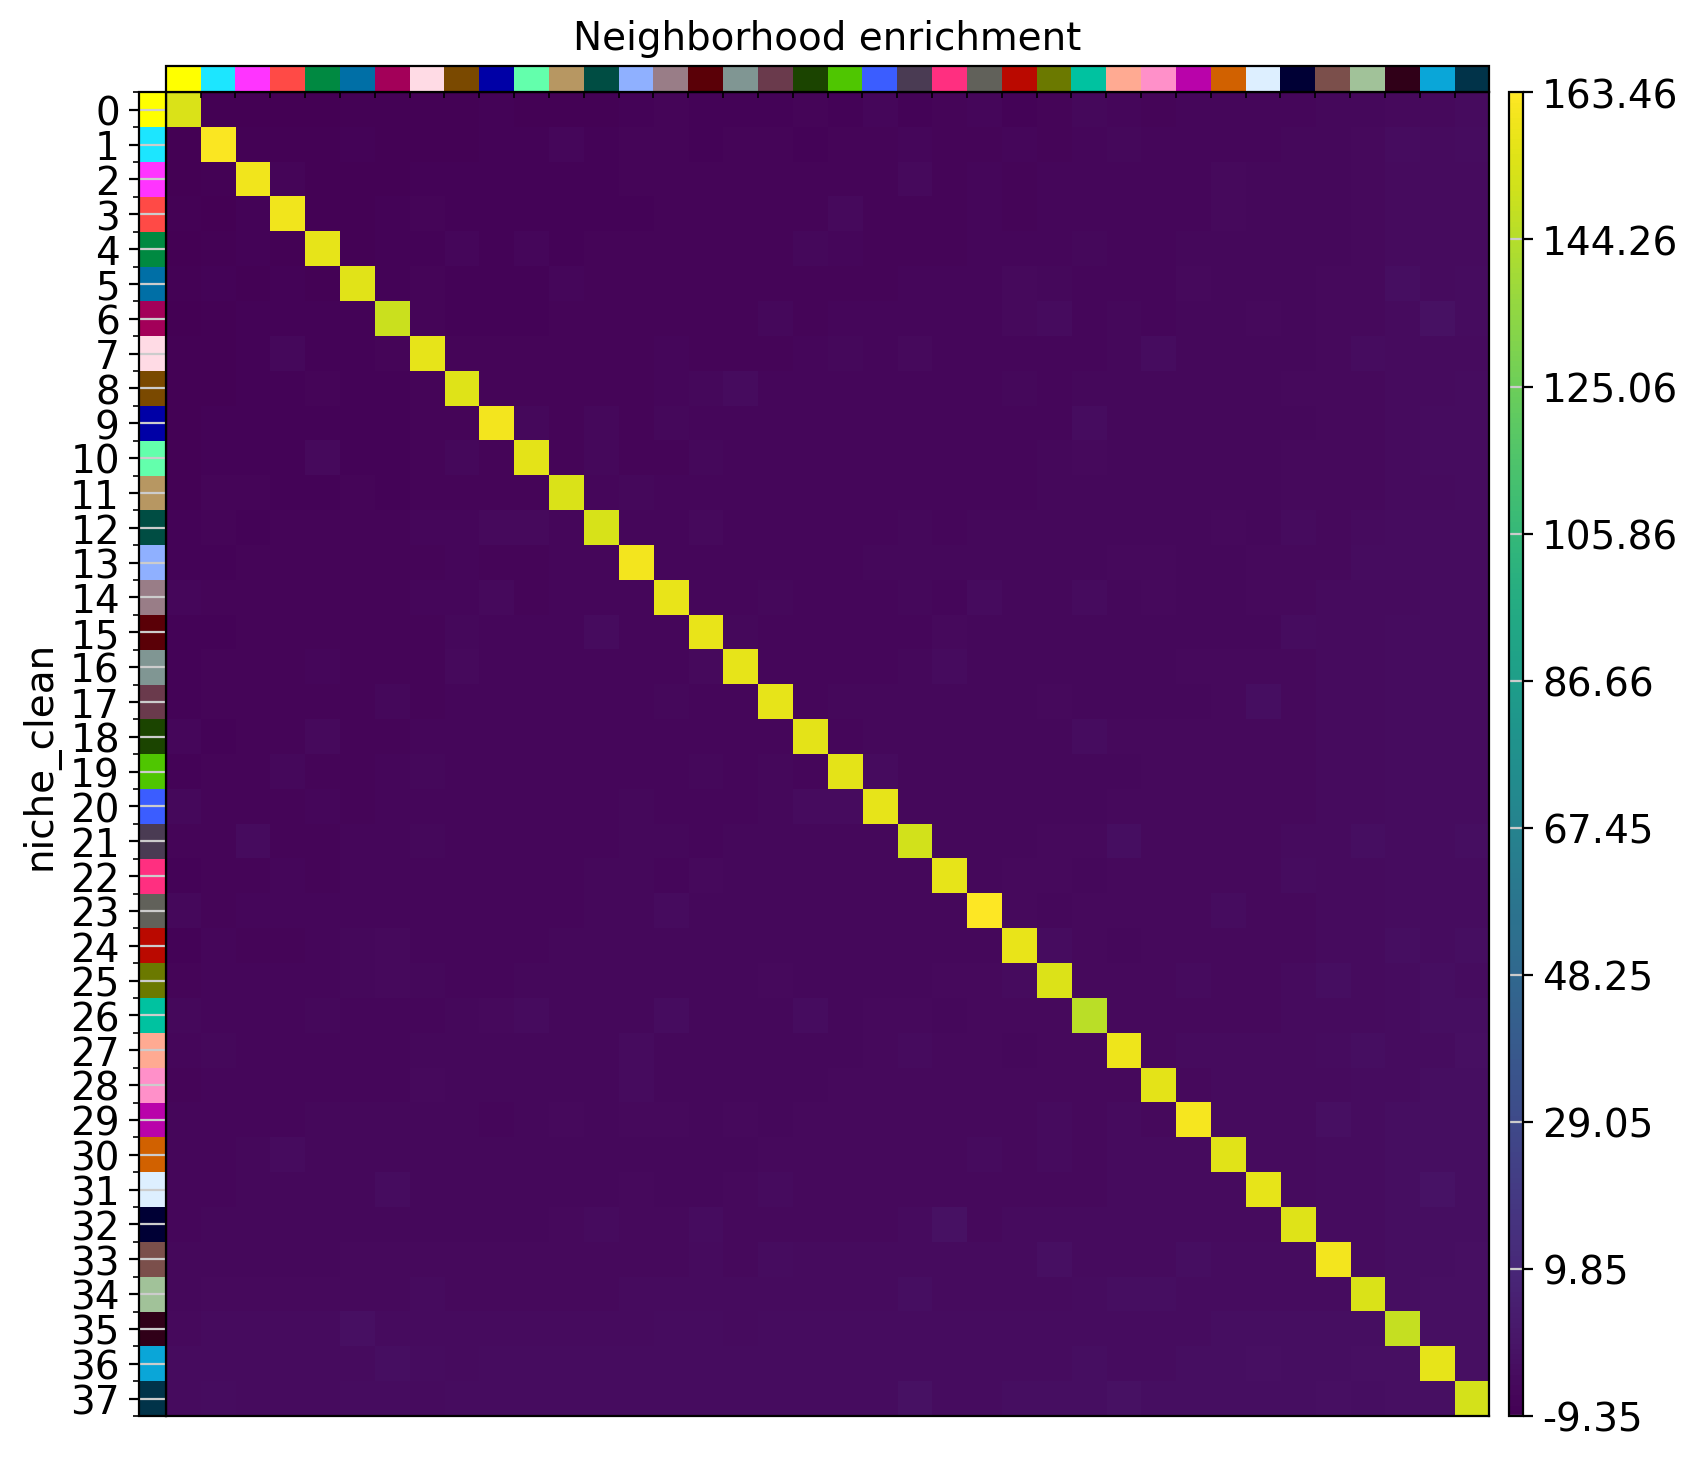

ERROR: Unable to fetch palette, reason: 'niche_clean_colors'. Using `None`.


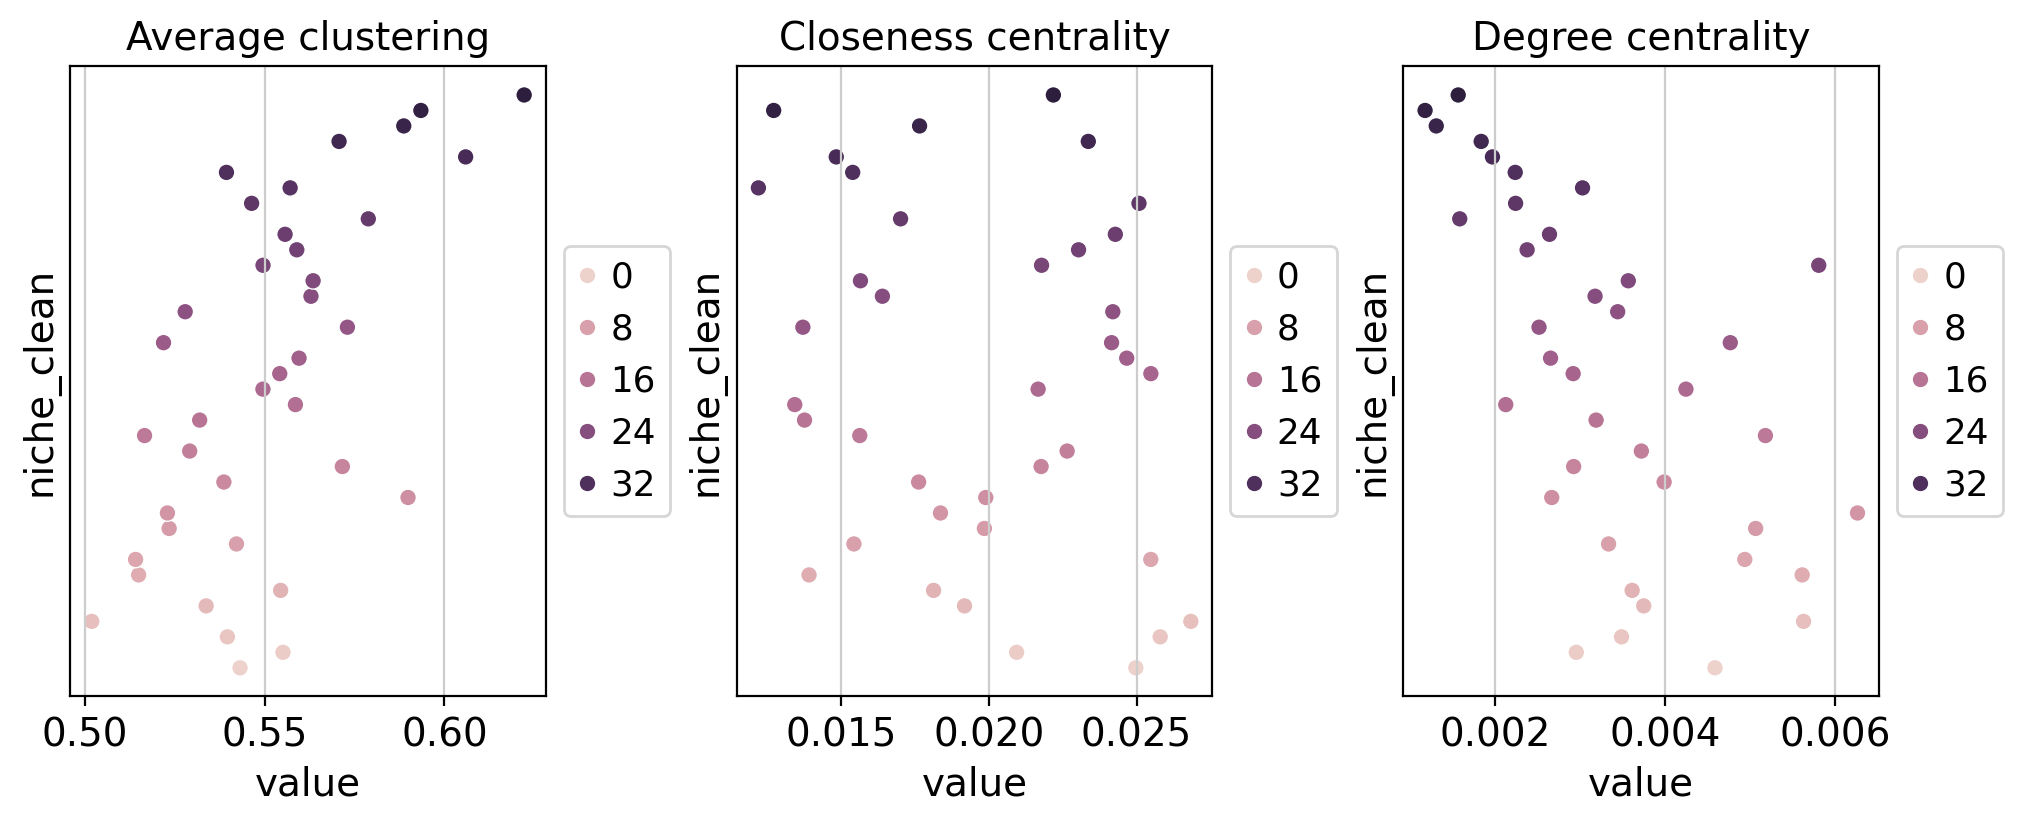

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


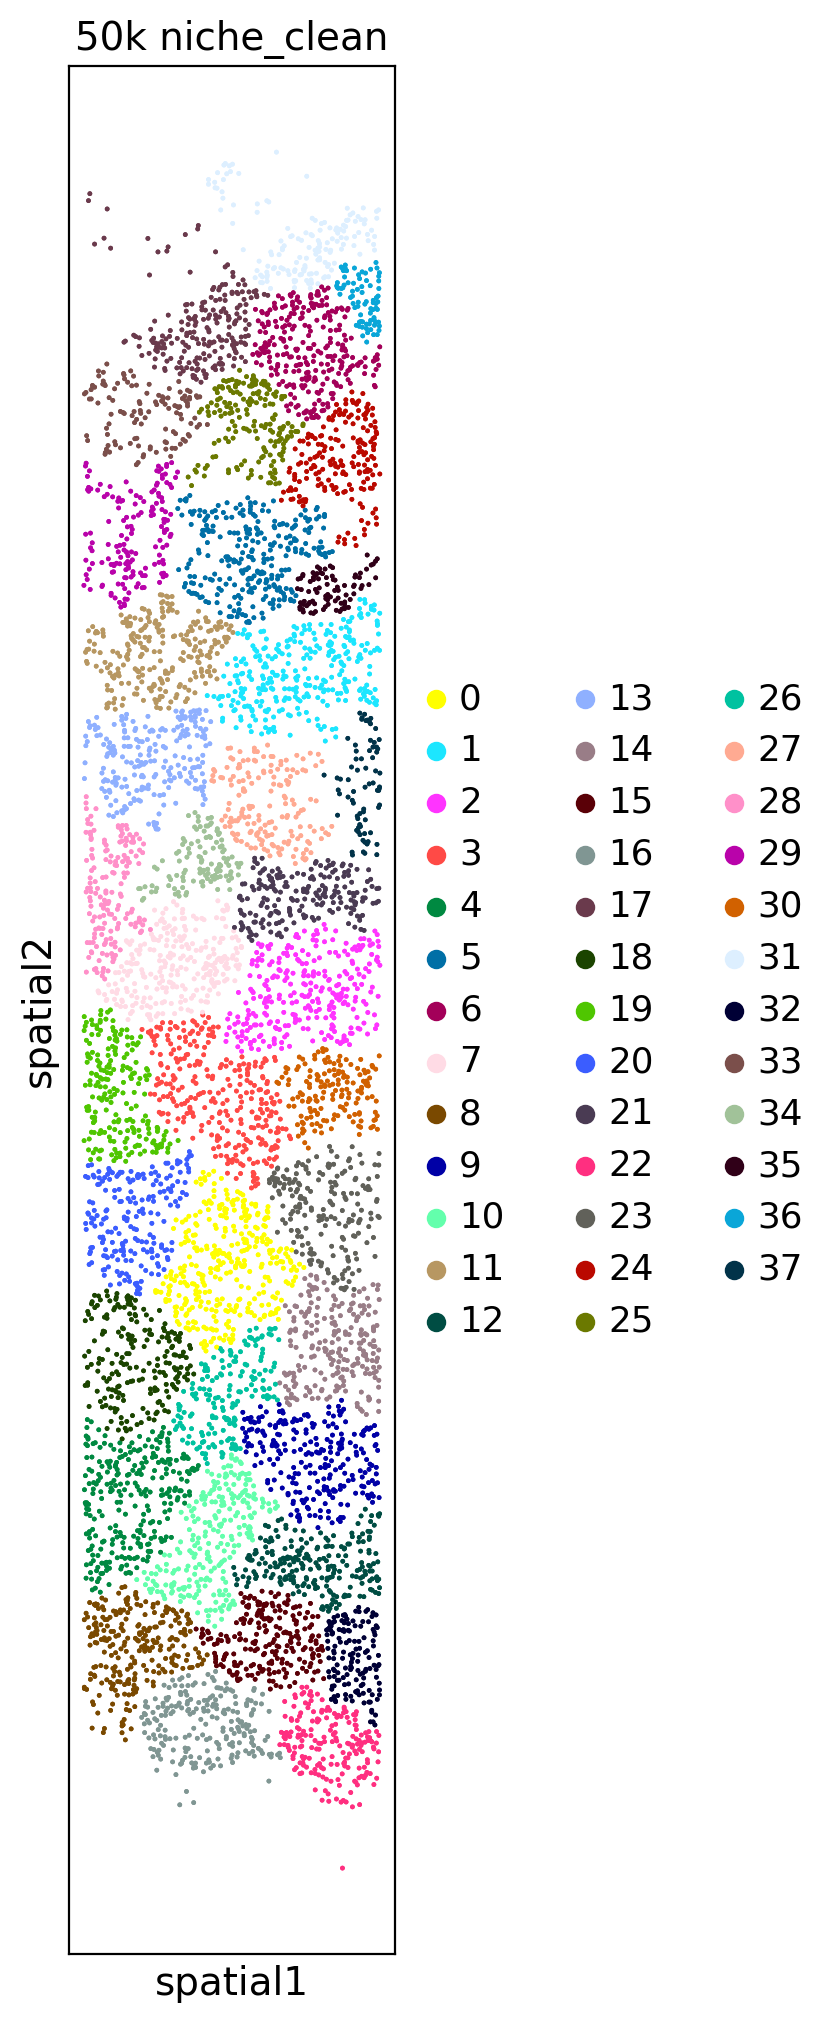

saved: /content/drive/MyDrive/CBMF4761/results/50k_squidpy.h5ad


In [ ]:
import os
import sys

if ENV == "colab":
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/CBMF4761"
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Make notebooks/ importable regardless of cwd.
# Corrected path to where utils.py is actually located in Google Drive
_NB_DIR = "/content/drive/MyDrive/Colab Notebooks"
if _NB_DIR not in sys.path:
    sys.path.insert(0, _NB_DIR)

from utils import apply_shims
apply_shims()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

sc.settings.set_figure_params(dpi=100, facecolor='white')

def run_squidpy_pipeline(sample_size):
    print(f"\n{'='*40}")
    print(f"Processing {sample_size} sampled dataset")
    print(f"{'='*40}\n")

    H5AD_PATH = os.path.join(DATA_DIR, f"lymph_node_{sample_size}_random3.h5ad")
    TOOL = 'squidpy'
    CT_KEY = 'niche_clean' # Changed from 'label1' to 'niche_clean'

    # 1. Load Data
    adata = sc.read_h5ad(H5AD_PATH)
    print(f"loaded: {adata.n_obs:,} cells x {adata.n_vars} features")

    # 1.1 Spatial Crop (Mirroring nicheMRF_inference.ipynb)
    coords = adata.obsm['spatial']
    mask = (
        (coords[:, 0] > 2000) & (coords[:, 0] < 3000) &
        (coords[:, 1] > 0000) & (coords[:, 1] < 6000)
    )
    adata = adata[mask].copy()
    print(f"n_cells after spatial crop: {adata.n_obs}")

    # 2. Spatial network
    # Handle NaN coordinates
    _spatial_key = 'spatial'
    if _spatial_key in adata.obsm:
        _coords = adata.obsm[_spatial_key]
        _nan_mask = np.isnan(_coords).any(axis=1)
        if _nan_mask.sum() > 0:
            print(f"Dropping {int(_nan_mask.sum()):,} cells with NaN spatial coordinates")
            adata = adata[~_nan_mask].copy()

    sq.gr.spatial_neighbors(adata, coord_type='generic', n_neighs=6)

    # 2.1 Leiden clustering (with Louvain fallback)
    try:
        sc.tl.leiden(
            adata,
            adjacency=adata.obsp['spatial_connectivities'],
            resolution=0.5,
            key_added='squidpy_niche',
            random_state=0,
        )
    except (ImportError, ModuleNotFoundError, RuntimeError) as e:
        print(f'Warning: Leiden clustering failed ({e}). Falling back to Louvain.')
        try:
            sc.tl.louvain(
                adata,
                adjacency=adata.obsp['spatial_connectivities'],
                resolution=0.5,
                key_added='squidpy_niche',
                random_state=0,
            )
        except Exception as e2:
            raise RuntimeError(f'Both Leiden and Louvain clustering failed. Error: {e2}')

    # 2.2 Simulate soft probabilities Q for Squidpy hard labels
    NICHE_KEY = 'squidpy_niche'
    labels_raw = adata.obs[NICHE_KEY].astype('category').cat.codes.values
    K = len(np.unique(labels_raw))
    Q = np.zeros((adata.n_obs, K))
    Q[np.arange(adata.n_obs), labels_raw] = 1.0
    adata.obsm["niche_mrf_soft"] = Q

    # --- Clean cluster extraction (Post-Processing) ---
    from scipy.stats import entropy
    from collections import deque

    Q = adata.obsm["niche_mrf_soft"]
    labels = adata.obs[NICHE_KEY].astype('category').cat.codes.values
    n_nodes, K = Q.shape
    A = adata.obsp["spatial_connectivities"].tocsr()

    # 1. Confidence filtering
    max_prob = Q.max(axis=1)
    margin = np.sort(Q, axis=1)[:, -1] - np.sort(Q, axis=1)[:, -2]
    q_entropy = entropy(Q.T)
    confident = (max_prob >= 0.05) & (margin >= 0.10) & (q_entropy <= 2.0)

    # 2. Spatial connected-component filtering
    def connected_components_for_mask(mask, adj):
        nodes = np.where(mask)[0]
        node_set = set(nodes.tolist())
        comp = np.full(adj.shape[0], -1, dtype=int)
        comp_id = 0
        visited = set()
        for start in nodes:
            if start in visited: continue
            queue = deque([start])
            while queue:
                n = queue.popleft()
                if n in visited: continue
                visited.add(n)
                comp[n] = comp_id
                for nb in adj.indices[adj.indptr[n]:adj.indptr[n+1]]:
                    if nb in node_set and nb not in visited: queue.append(nb)
            comp_id += 1
        return comp

    clean_labels = np.full(n_nodes, -1, dtype=int)
    for k in range(K):
        mask_k = (labels == k) & confident
        if mask_k.sum() == 0: continue
        comp = connected_components_for_mask(mask_k, A)
        comp_ids, comp_sizes = np.unique(comp[comp >= 0], return_counts=True)
        keep_threshold = max(10, 0.01 * mask_k.sum())
        for cid, csz in zip(comp_ids, comp_sizes):
            if csz >= keep_threshold: clean_labels[(comp == cid)] = k

    # 3. Gap filling
    for _ in range(10):
        unassigned = np.where(clean_labels == -1)[0]
        if len(unassigned) == 0: break
        changed = 0
        for i in unassigned:
            nb_idx = A.indices[A.indptr[i]:A.indptr[i+1]]
            nb_labels = clean_labels[nb_idx]
            assigned_nb = nb_labels[nb_labels >= 0]
            if len(assigned_nb) == 0: continue
            vals, counts = np.unique(assigned_nb, return_counts=True)
            if counts.max() / len(nb_idx) >= 0.60:
                clean_labels[i] = vals[counts.argmax()]
                changed += 1
        if changed == 0: break

    # 4. Pruning and Relabeling
    final_ids, final_sizes = np.unique(clean_labels[clean_labels >= 0], return_counts=True)
    for sc_id in final_ids[final_sizes < 5]: clean_labels[clean_labels == sc_id] = -1
    surviving = np.array(sorted(set(clean_labels[clean_labels >= 0]), key=lambda k: -(clean_labels == k).sum()))
    remap = {old: new for new, old in enumerate(surviving)}
    final_labels = np.where(clean_labels >= 0, np.vectorize(remap.get)(clean_labels, -1), -1)
    adata.obs["niche_clean"] = pd.Categorical(final_labels) # Convert to categorical using pandas
    adata.obs["niche_clean_int"] = final_labels

    # 5. Standardized Niche Visualization (4-panel)
    import matplotlib.pyplot as plt
    coords = adata.obsm["spatial"]
    final_labels = adata.obs["niche_clean_int"].values
    Q = adata.obsm["niche_mrf_soft"]
    max_prob = Q.max(axis=1)
    niches = sorted(i for i in np.unique(final_labels) if i >= 0)
    n_niche = len(niches)
    cmap_cat = plt.get_cmap("tab20", max(n_niche, 1))
    niche_colors = {n: cmap_cat(i) for i, n in enumerate(niches)}
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(f"{sample_size} - {TOOL.capitalize()} Niche Post-processing", fontsize=14, fontweight="bold", y=1.01)
    ax = axes[0, 0]
    unassigned = final_labels == -1
    ax.scatter(coords[unassigned, 0], coords[unassigned, 1], c="lightgray", s=4, linewidths=0, rasterized=True, label="unassigned")
    for niche_id in niches:
        mask = final_labels == niche_id
        ax.scatter(coords[mask, 0], coords[mask, 1], c=[niche_colors[niche_id]], s=5, linewidths=0, rasterized=True, label=f"niche {niche_id}")
    ax.set_title("Spatial niche map"); ax.set_aspect("equal")
    ax.legend(markerscale=2, fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    ax = axes[0, 1]
    sp = ax.scatter(coords[:, 0], coords[:, 1], c=max_prob, cmap="plasma", vmin=0, vmax=1, s=5, linewidths=0, rasterized=True)
    plt.colorbar(sp, ax=ax, label="peak Q (confidence)", shrink=0.85)
    ax.set_title("Posterior confidence"); ax.set_aspect("equal")
    ax = axes[1, 0]; ax2 = ax.twinx()
    sizes = [np.sum(final_labels == n) for n in niches]
    mean_conf = [max_prob[final_labels == n].mean() for n in niches]
    bar_colors = [niche_colors[n] for n in niches]; x = np.arange(n_niche)
    ax.bar(x, sizes, color=bar_colors, width=0.6, alpha=0.85)
    ax2.plot(x, mean_conf, "k--o", markersize=4, linewidth=1.2, label="mean confidence")
    ax2.set_ylim(0, 1.05); ax.set_xticks(x); ax.set_xticklabels([str(n) for n in niches], fontsize=7)
    ax.set_title("Cluster size and mean confidence")
    ax = axes[1, 1]; assigned_mask = final_labels >= 0
    idx_sorted = np.argsort(final_labels[assigned_mask])
    Q_plot = Q[assigned_mask][idx_sorted]
    if Q_plot.shape[0] > 2000: step = Q_plot.shape[0] // 2000; Q_plot = Q_plot[::step]
    im = ax.imshow(Q_plot, aspect="auto", cmap="Oranges", vmin=0, vmax=1, interpolation="nearest")
    plt.colorbar(im, ax=ax, label="responsibility Q", shrink=0.85)
    ax.set_title("Soft assignment matrix Q"); ax.set_xticks(np.arange(Q.shape[1]))
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{sample_size}_{TOOL}_mrf_niches.png"), dpi=200)
    plt.show()

    # 3. Neighborhood enrichment
    sq.gr.nhood_enrichment(adata, cluster_key=CT_KEY)
    sq.pl.nhood_enrichment(adata, cluster_key=CT_KEY, figsize=(7, 7))
    plt.savefig(os.path.join(RESULTS_DIR, f"{sample_size}_{TOOL}_nhood_enrichment.png"), dpi=200)
    plt.show()

    # 4. Centrality scores
    sq.gr.centrality_scores(adata, cluster_key=CT_KEY)
    sq.pl.centrality_scores(adata, cluster_key=CT_KEY, figsize=(10, 4))
    plt.savefig(os.path.join(RESULTS_DIR, f"{sample_size}_{TOOL}_centrality.png"), dpi=200)
    plt.show()

    # 5. Spatial scatter
    sq.pl.spatial_scatter(
        adata,
        color=CT_KEY,
        shape=None,
        size=2,
        title=f'{sample_size} {CT_KEY}',
        figsize=(10, 10),
    )
    plt.savefig(os.path.join(RESULTS_DIR, f"{sample_size}_{TOOL}_spatial.png"), dpi=200)
    plt.show()

    # 6. Persist annotated AnnData
    OUT_H5AD = os.path.join(RESULTS_DIR, f"{sample_size}_{TOOL}.h5ad")
    adata.write_h5ad(OUT_H5AD)
    print('saved:', OUT_H5AD)

for size in ['5k', '50k']:
    run_squidpy_pipeline(size)